In [ ]:
#rule based classification 

import pandas as pd
import re
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

# load both datasets
court_df = pd.read_csv("data/indiasandwatch/court_docs.csv", header=1)
obs_df = pd.read_csv("data/indiasandwatch/mining_obs.csv", header=1)

# clean column names
court_df.columns = [c.strip() for c in court_df.columns]
obs_df.columns = [c.strip() for c in obs_df.columns]

In [71]:
district_survey = pd.read_csv("data/indiasandwatch/district_survey_reports.csv", header=1)

In [74]:
district_survey.shape

(91, 664)

In [75]:
district_survey.head(5)

,Title,State,District,Link,PDF,Does the District Survey Report identify new mining sites?,Number of streams identified for mining,Rivers / Streams,Total number of Identified/ proposed mining locations,Total Sand Potential,...,Identified Mining Locations / Quarries.100.Area in Hectare (Ha.),Identified Mining Locations / Quarries.100.Name of the quarry,Identified Mining Locations / Quarries.100.Polygon points,Identified Mining Locations / Quarries.100.Rivers / Streams,Identified Mining Locations / Quarries.100.Sub district name,Identified Mining Locations / Quarries.101.Area in Hectare (Ha.),Identified Mining Locations / Quarries.101.Name of the quarry,Identified Mining Locations / Quarries.101.Polygon points,Identified Mining Locations / Quarries.101.Rivers / Streams,Identified Mining Locations / Quarries.101.Sub district name
0,Coimbatore,Tamil Nadu,Coimbatore,https://coimbatore.nic.in/document/district-survey-report-for-sand-mining/,https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/pdfs%2F20a649a7-e730-43fc-9248-b914c98f8c44.pdf?generation=1667392500318076&alt=media,NaN,NaN,"Noyyal, Bhavani, Aliyar",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mahendragarh,Haryana,Mahendragarh,https://mahendragarh.gov.in/document-category/district-survey-report-for-sustainable-sand-mining/,https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/pdfs%2F6032f513-ab69-457e-a752-a3e0d69594d2.pdf?generation=1667459001726025&alt=media,NaN,NaN,"Krishnawati, Dohan",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Baleshwar, 2019",Odisha,Baleshwar,https://baleswar.nic.in/notice/district-survey-report-of-minor-mineralsriver-sand-2/,https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/pdfs%2F63c1efbc-a560-415b-b2e6-feebda256561.pdf?generation=1667832570880393&alt=media,NaN,5.0,"Budhabalanga , Jalaka , Sona , Kansbans , Subarnarekha",55.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Sidhi,Madhya Pradesh,Sidhi,https://cdn.s3waas.gov.in/s36c4b761a28b734fe93831e3fb400ce87/uploads/2022/06/2022060155.pdf,https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/pdfs%2Fsidhi_dsr_55c16272-b21f-448b-81c6-3120a98c950e.pdf?generation=1742371827706385&alt=media,NaN,3.0,"Sone , Gopad, Banas",8.0,Cubic meters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Yavatmal, 2021",Maharashtra,Yavatmal,https://yavatmal.gov.in/notice/final-district-survey-report-2020-part-1/,https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/pdfs%2Ff392650b-154c-4447-a54c-7a9f7ac1e59c.pdf?generation=1667896906848906&alt=media,NaN,5.0,"Wardha, Penganga, Pus, Nirguda, Bembala",86.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
court_df.head(1)

,Title,Link to the case on court sites / other sites,PDF,Type of Document,Summary,Start Date/ Registration date/ original application date of the case (as applicable),Application number / case number / diary number (as applicable),Type of Application,Case status,Date of case disposal,...,District,Sub district / Tehsil,Rivers / Streams,Court,High Court,National Green Tribunal (NGT) zone/bench,Published Date,clean_summary,legal_patterns,is_illegal_case
0,"Deepak Kumar Etc vs State Of Haryana & Ors.Etc on 27 February, 2012","https://indiankanoon.org/doc/60071241/#:~:text=Deepak%20Kumar%20Etc%20vs%20State,Etc%20on%2027%20February%2C%202012",https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/pdfs%2F7cbf7067-166d-4e3d-a20b-3c9bacea9f61.PDF?generation=1674054480108411&alt=media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"yamuna, Ghaggar, Tangri, Markanda, Krishnavati, Dohan",Supreme Court,NaN,NaN,06-01-2023,,[],0


In [69]:
obs_df.head(1)

,Title,Would you like to submit this report anonymously?,Date of Observation,Location,Are machines used in the process?,Can you specify types of machines/ equipment,Notes from the location,Pictures,State,District,...,has_active_mining,risk_night,risk_high_volume,risk_repeat,field_illegal,legal_score,final_score,illegality_class,score_breakdown,missing_signals
0,"Tribeni - Hooghly / Bhagirathi River, 2016",NaN,17-06-2016 18:30:00,"Serial Number,Latitude,Longitude\n1,22.973344,88.405614\n",Yes,Pumps loaded on to boats were being used.,Possibly bottom dredgers which then transport the extracted material via pipes to the riverbank,https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/images%2Fimg_20160617_103012_56a865c7-7bdf-4f1c-9275-16b84ba22303.jpeg?generation=1687766819526489&alt=media,West Bengal,Murshidabad,...,0,0,0,0,0,0,3.0,highly_likely_illegal,"{'machinery': 0, 'transport': 3, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 0, 'total': 3.0}","[machinery, illegal_language, legal_match]"


In [22]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

court_df["clean_summary"] = court_df["Summary"].apply(clean_text)
obs_df["clean_notes"] = obs_df["Notes from the location"].apply(clean_text)

In [23]:
LEGAL_REGEX_PATTERNS = [
    r"illegal.*mining",
    r"unauthori[sz]ed",
    r"without.*permission",
    r"without.*clearance",
    r"no.*clearance",
    r"beyond.*limit",
    r"excess.*mining",
    r"lease.*violation",
    r"environment.*violation"
]

In [24]:
def match_legal_patterns(text):
    matches = []
    for pattern in LEGAL_REGEX_PATTERNS:
        if re.search(pattern, text):
            matches.append(pattern)
    return matches

court_df["legal_patterns"] = court_df["clean_summary"].apply(match_legal_patterns)

print("Court pattern distribution:")
print(Counter(sum(court_df["legal_patterns"], [])))

Court pattern distribution:
Counter({'illegal.*mining': 63, 'no.*clearance': 26, 'environment.*violation': 22, 'without.*clearance': 14, 'unauthori[sz]ed': 12, 'lease.*violation': 8, 'without.*permission': 7, 'excess.*mining': 3, 'beyond.*limit': 3})


In [25]:
ACTIVITY_PATTERNS = {
    "machinery": r"jcb|poclain|excavator|machine|heavy equipment",
    "transport": r"truck|tractor|trolley|vehicle|transport",
    "active_mining": r"mining (going on|happening|active)"
}

RISK_PATTERNS = {
    "night": r"night|midnight|dark",
    "high_volume": r"large quantity|heavy mining|intensive",
    "repeat": r"regular|daily|frequent"
}

ILLEGAL_FIELD_PATTERNS = [
    r"illegal",
    r"without permit",
    r"no permission",
    r"unauthorized"
]

In [26]:
def count_pattern(text, pattern):
    return 1 if re.search(pattern, text) else 0


# activity signals
for key, pattern in ACTIVITY_PATTERNS.items():
    obs_df[f"has_{key}"] = obs_df["clean_notes"].apply(
        lambda x: count_pattern(x, pattern)
    )

# risk signals
for key, pattern in RISK_PATTERNS.items():
    obs_df[f"risk_{key}"] = obs_df["clean_notes"].apply(
        lambda x: count_pattern(x, pattern)
    )

# legal signals (field language)
obs_df["field_illegal"] = obs_df["clean_notes"].apply(
    lambda x: any(re.search(p, x) for p in ILLEGAL_FIELD_PATTERNS)
).astype(int)

In [27]:
def legal_match_score(text):
    score = 0
    for pattern in LEGAL_REGEX_PATTERNS:
        if re.search(pattern, text):
            score += 2
    return score

obs_df["legal_score"] = obs_df["clean_notes"].apply(legal_match_score)

In [28]:
def compute_score(row):
    score = 0
    
    # strong signals
    score += 3 * row["has_machinery"]
    score += 3 * row["has_transport"]
    
    # medium signals
    score += 2 * row["field_illegal"]
    
    # risk amplification
    score += 1.5 * row["risk_night"]
    score += 1.5 * row["risk_high_volume"]
    score += 1 * row["risk_repeat"]
    
    # legal alignment
    score += row["legal_score"]
    
    return score

obs_df["final_score"] = obs_df.apply(compute_score, axis=1)

In [29]:
q1 = obs_df["final_score"].quantile(0.5)
q2 = obs_df["final_score"].quantile(0.8)

def classify(score):
    if score >= q2:
        return "highly_likely_illegal"
    elif score >= q1:
        return "possibly_illegal"
    else:
        return "uncertain"

obs_df["illegality_class"] = obs_df["final_score"].apply(classify)

In [30]:
print(obs_df["illegality_class"].value_counts())

illegality_class
possibly_illegal         254
highly_likely_illegal    121
Name: count, dtype: int64


In [31]:
obs_df.sort_values("final_score", ascending=False)[
    ["Notes from the location", "final_score"]
].head(10)

,Notes from the location,final_score
50,- Location was close to Dobhiyai village very ...,11.5
63,I noticed many tractor marks - two kinds of ma...,10.0
373,"Instream mining, temporary roads created in th...",10.0
369,The lease boundary given by government on the ...,10.0
26,"Illegal sand mining in the Chambal River, Nati...",7.0
53,This mining activity was observed from the bam...,7.0
195,Due to easy access to the main road a huge min...,6.0
46,"- Location is Tiletha village, Barsula panchay...",6.0
54,"Observed 13 Trucks, 1 excavator. Active mining...",6.0
56,Lots of mining on both North and South banks o...,6.0


In [33]:
obs_df.groupby("State")["final_score"].mean().sort_values(ascending=False)

#relative scoring

State
Goa                 6.000000
Himachal Pradesh    4.500000
Madhya Pradesh      3.639535
Rajasthan           3.625000
Uttar Pradesh       2.625000
West Bengal         2.416667
Maharashtra         1.750000
Jharkhand           1.333333
Odisha              1.000000
Bihar               0.357513
Karnataka           0.250000
Gujarat             0.000000
Name: final_score, dtype: float64

In [34]:
def score_breakdown(row):
    breakdown = {}
    
    # strong signals
    breakdown["machinery"] = 3 * row["has_machinery"]
    breakdown["transport"] = 3 * row["has_transport"]
    
    # field illegality
    breakdown["field_illegal"] = 2 * row["field_illegal"]
    
    # risks
    breakdown["night"] = 1.5 * row["risk_night"]
    breakdown["high_volume"] = 1.5 * row["risk_high_volume"]
    breakdown["repeat"] = 1 * row["risk_repeat"]
    
    # legal alignment
    breakdown["legal"] = row["legal_score"]
    
    breakdown["total"] = sum(breakdown.values())
    
    return breakdown

In [35]:
obs_df["score_breakdown"] = obs_df.apply(score_breakdown, axis=1)

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

possibly = obs_df[obs_df["illegality_class"] == "possibly_illegal"]

possibly[[
    "Notes from the location",
    "final_score",
    "score_breakdown"
]].head(5)

,Notes from the location,final_score,score_breakdown
7,Location was being mined at this time. Information was gathered a couple of months later when visiting this location.,0.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 0, 'total': 0.0}"
9,Observed through an aerial route and confirmed with remote sensing information for the same period.,0.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 0, 'total': 0.0}"
10,Observed through aerial route and confirmed through remote sensing information for the same period. The situation only worsens post date of observations. Severe mining signs visible in 2022 and 2023.,0.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 0, 'total': 0.0}"
13,Multiple small operations at the exact GPS location. Material is collected and then transferred to a nearby processing facility for grading. Other locations + processing centre is in proximity. Signals continue to be visible in later years as well.,0.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 0, 'total': 0.0}"
15,This location sees excessive mining of riverbed material. Visible mostly is the gravel and stone mining. However given the presence of a large number of brick kilns also indicate extraction of clay from the riverbed and nearby areas.,2.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 2, 'total': 2.0}"


In [37]:
high = obs_df[obs_df["illegality_class"] == "highly_likely_illegal"]

print("POSSIBLY ILLEGAL (avg breakdown):")
print(pd.DataFrame(list(possibly["score_breakdown"])).mean())

print("\nHIGHLY LIKELY ILLEGAL (avg breakdown):")
print(pd.DataFrame(list(high["score_breakdown"])).mean())

POSSIBLY ILLEGAL (avg breakdown):
machinery        0.000000
transport        0.000000
field_illegal    0.007874
night            0.005906
high_volume      0.000000
repeat           0.003937
legal            0.015748
total            0.033465
dtype: float64

HIGHLY LIKELY ILLEGAL (avg breakdown):
machinery        1.809917
transport        1.685950
field_illegal    0.380165
night            0.061983
high_volume      0.000000
repeat           0.000000
legal            0.363636
total            4.301653
dtype: float64


In [47]:
threshold = obs_df["final_score"].quantile(0.8)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

borderline = obs_df[
    (obs_df["final_score"] >= threshold - 1) &
    (obs_df["final_score"] < threshold)
]

borderline[[
    "Notes from the location",
    "final_score",
    "score_breakdown"
]].head(10)

,Notes from the location,final_score,score_breakdown
15,This location sees excessive mining of riverbed material. Visible mostly is the gravel and stone mining. However given the presence of a large number of brick kilns also indicate extraction of clay from the riverbed and nearby areas.,2.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 2, 'total': 2.0}"
57,"Interviews with locals lead us to believe that mining had stopped for about a month prior to the visit (~ Feb 1, 2024). The miners have built a very illegal rickety (mostly land) bridge across the Subernarekha to aid extraction, and charge Rs 100 toll tax to 4+ wheelers. There were signs of multiple older bridges on the ground and in sat. imagery. Locals also told us that the bridges tend to be swept away during the monsoons. The river flow is highly restricted and controlled in this portion of the river. There were a large number of circular or oval holes in the sand filled with water, a clear sign of jet suction. It is actually in Jhargram district",2.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 2, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 0, 'total': 2.0}"
200,"मल्हा,मांझी और मछुआरा समुदाय जो पहले नाव चलाने और मछली पकड़ने का काम करते थे। अब वे भी माइनिंग गतिविधियों का हिस्सा बन रहे हैं क्यों कि बहुत ज्यादा खनन से नदी में पानी और मछलीयां दोनों खत्म हो गए जिससे ये समुदाय बेरोजगार हो गए हैं।\n\n\nTranslation: Fishing and boating communities have now started participating in sand mining activities as the excessive sand mining activity in this region has resulted in massive reduction of water and fish in the river. This has led to unemployment for these communities, and hence a move towards activities such as sand mining.\n\n\nThis case report has been generated based on sightings of sand mining from the India Sand Watch and Veditum network. Have observations of sand mining in Indian rivers? Upload them directly to India Sand Watch or email the details to us at - \nsandwatch@veditum.org",2.0,"{'machinery': 0, 'transport': 0, 'field_illegal': 0, 'night': 0.0, 'high_volume': 0.0, 'repeat': 0, 'legal': 2, 'total': 2.0}"


In [39]:
def missing_signals(row):
    missing = []
    
    if row["has_machinery"] == 0:
        missing.append("machinery")
    if row["has_transport"] == 0:
        missing.append("transport")
    if row["field_illegal"] == 0:
        missing.append("illegal_language")
    if row["legal_score"] == 0:
        missing.append("legal_match")
        
    return missing

obs_df["missing_signals"] = obs_df.apply(missing_signals, axis=1)

The model identifies potential illegal sand mining based on three classes of indicators:
(1) operational signals such as machinery and transport activity,
(2) contextual risk signals such as nighttime or high-volume extraction, and
(3) legal indicators derived from court-recognized definitions of illegal mining, including unauthorized extraction and violations of environmental clearance requirements.

for an activity to be marked highly_likely_illegal, we need (1) definitely, and presence of (2) or (3) 

possibly_illegal are marked if (1) exists but (2) or (3) don't. we currently are not analyzing for if something looks legal (don't have the data yet)

In [48]:
high_illegal_by_state = (
    obs_df[obs_df["illegality_class"] == "highly_likely_illegal"]
    .groupby("State")
    .size()
    .sort_values(ascending=False)
)

print(high_illegal_by_state.head(10))

State
Uttar Pradesh       32
Madhya Pradesh      30
West Bengal         25
Bihar               19
Rajasthan            7
Maharashtra          3
Goa                  1
Himachal Pradesh     1
Jharkhand            1
Karnataka            1
dtype: int64


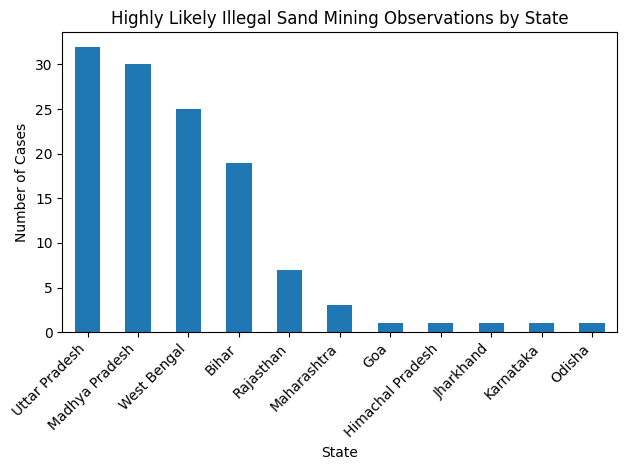

In [49]:
import matplotlib.pyplot as plt

plt.figure()
high_illegal_by_state.head(15).plot(kind="bar")

plt.title("Highly Likely Illegal Sand Mining Observations by State")
plt.xlabel("State")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
# total reports per state
total_by_state = obs_df.groupby("State").size()

# proportion of highly illegal
ratio = (high_illegal_by_state / total_by_state).sort_values(ascending=False)

print(ratio.head(10))

State
Goa                 1.000000
Himachal Pradesh    1.000000
Rajasthan           0.875000
Madhya Pradesh      0.697674
Uttar Pradesh       0.666667
West Bengal         0.520833
Maharashtra         0.500000
Jharkhand           0.333333
Odisha              0.333333
Bihar               0.098446
dtype: float64


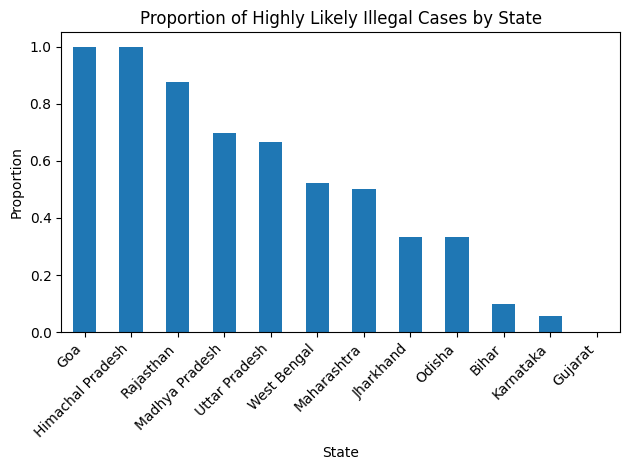

In [51]:
plt.figure()
ratio.head(15).plot(kind="bar")

plt.title("Proportion of Highly Likely Illegal Cases by State")
plt.xlabel("State")
plt.ylabel("Proportion")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [52]:
court_df["is_illegal_case"] = court_df["legal_patterns"].apply(lambda x: len(x) > 0).astype(int)

In [53]:
# total cases per state
court_total = court_df.groupby("State").size()

# illegal cases per state
court_illegal = court_df.groupby("State")["is_illegal_case"].sum()

# normalized
court_rate = (court_illegal / court_total).fillna(0)

In [54]:
# total observations per state
obs_total = obs_df.groupby("State").size()

# highly likely illegal cases
obs_illegal = (
    obs_df[obs_df["illegality_class"] == "highly_likely_illegal"]
    .groupby("State")
    .size()
)

# normalized
obs_rate = (obs_illegal / obs_total).fillna(0)

In [55]:
all_states = set(court_rate.index).union(set(obs_rate.index))

court_rate = court_rate.reindex(all_states, fill_value=0)
obs_rate = obs_rate.reindex(all_states, fill_value=0)

In [56]:
gap = (obs_rate - court_rate).sort_values(ascending=False)

print(gap.head(10))

State
Himachal Pradesh    1.000000
West Bengal         0.520833
Jharkhand           0.333333
Gujarat             0.000000
Goa                 0.000000
Madhya Pradesh     -0.092648
Rajasthan          -0.125000
Uttar Pradesh      -0.190476
Karnataka          -0.444444
Haryana            -0.500000
dtype: float64


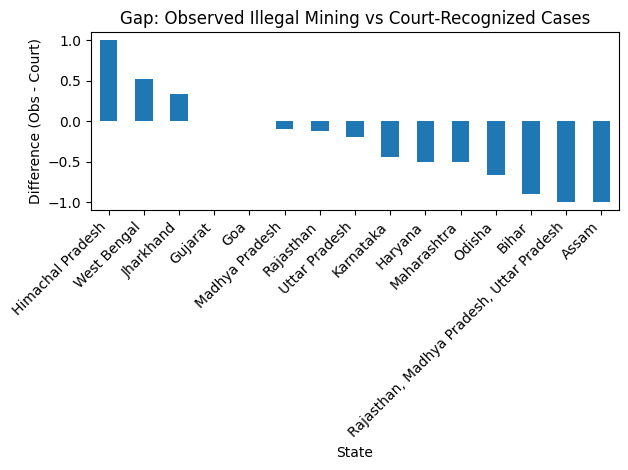

In [57]:
import matplotlib.pyplot as plt

plt.figure()
gap.head(15).plot(kind="bar")

plt.title("Gap: Observed Illegal Mining vs Court-Recognized Cases")
plt.xlabel("State")
plt.ylabel("Difference (Obs - Court)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

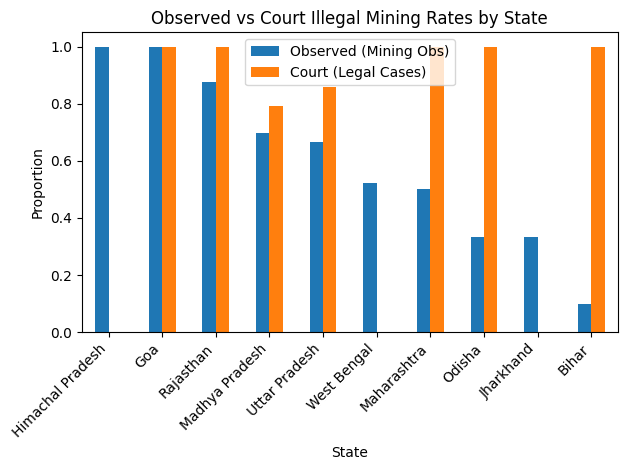

In [58]:
combined = pd.DataFrame({
    "Observed (Mining Obs)": obs_rate,
    "Court (Legal Cases)": court_rate
}).fillna(0)

combined = combined.sort_values("Observed (Mining Obs)", ascending=False)

combined.head(10).plot(kind="bar")

plt.title("Observed vs Court Illegal Mining Rates by State")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

analysis on gap states

In [ ]:
top_states = gap.sort_values(ascending=False).head(5).index.tolist()
top_states

['Himachal Pradesh', 'West Bengal', 'Jharkhand', 'Gujarat', 'Goa']

In [ ]:
def state_obs_profile(state):
    sub = obs_df[obs_df["State"] == state].copy()
    if len(sub) == 0:
        return None
    
    profile = {
        "n_obs": len(sub),
        "avg_score": sub["final_score"].mean(),
        "pct_high_illegal": (sub["illegality_class"] == "highly_likely_illegal").mean(),
        
        "machinery_rate": sub["has_machinery"].mean(),
        "transport_rate": sub["has_transport"].mean(),
        "night_rate": sub["risk_night"].mean(),
        "high_volume_rate": sub["risk_high_volume"].mean(),
        "repeat_rate": sub["risk_repeat"].mean(),
        "field_illegal_rate": sub["field_illegal"].mean(),
        "legal_match_rate": (sub["legal_score"] > 0).mean(),
    }
    return pd.Series(profile)

obs_profiles = pd.DataFrame([state_obs_profile(s) for s in top_states], index=top_states)
obs_profiles

,n_obs,avg_score,pct_high_illegal,machinery_rate,transport_rate,night_rate,high_volume_rate,repeat_rate,field_illegal_rate,legal_match_rate
Himachal Pradesh,1.0,4.500000,1.000000,1.000000,0.000000,1.0,0.0,0.0,0.000000,0.000000
West Bengal,48.0,2.416667,0.520833,0.333333,0.416667,0.0,0.0,0.0,0.041667,0.041667
Jharkhand,3.0,1.333333,0.333333,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.333333
Gujarat,3.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
Goa,1.0,6.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000


In [61]:
def state_court_profile(state):
    sub = court_df[court_df["State"] == state].copy()
    if len(sub) == 0:
        return pd.Series({
            "n_cases": 0,
            "illegal_case_rate": 0,
            "machinery_mentions": 0,
            "transport_mentions": 0
        })
    
    return pd.Series({
        "n_cases": len(sub),
        "illegal_case_rate": sub["is_illegal_case"].mean(),
        "machinery_mentions": sub["has_machinery"].mean() if "has_machinery" in sub else 0,
        "transport_mentions": sub["has_transport"].mean() if "has_transport" in sub else 0,
    })

court_profiles = pd.DataFrame([state_court_profile(s) for s in top_states], index=top_states)
court_profiles

,n_cases,illegal_case_rate,machinery_mentions,transport_mentions
Himachal Pradesh,0.0,0.0,0.0,0.0
West Bengal,0.0,0.0,0.0,0.0
Jharkhand,0.0,0.0,0.0,0.0
Gujarat,0.0,0.0,0.0,0.0
Goa,2.0,1.0,0.0,0.0


In [62]:
comparison = pd.concat([obs_profiles, court_profiles], axis=1)
comparison

,n_obs,avg_score,pct_high_illegal,machinery_rate,transport_rate,night_rate,high_volume_rate,repeat_rate,field_illegal_rate,legal_match_rate,n_cases,illegal_case_rate,machinery_mentions,transport_mentions
Himachal Pradesh,1.0,4.500000,1.000000,1.000000,0.000000,1.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
West Bengal,48.0,2.416667,0.520833,0.333333,0.416667,0.0,0.0,0.0,0.041667,0.041667,0.0,0.0,0.0,0.0
Jharkhand,3.0,1.333333,0.333333,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0
Gujarat,3.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
Goa,1.0,6.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,2.0,1.0,0.0,0.0


In [63]:
state = top_states[0]

obs_df[
    (obs_df["State"] == state) &
    (obs_df["illegality_class"] == "highly_likely_illegal")
][["Notes from the location", "final_score"]].head(10)

,Notes from the location,final_score
188,Day time collections were being made by people collecting riverbed material into dumpers. But it seemed like night time mining was being done using larger machines.\n\n\nThis case report has been generated based on sightings of sand mining from the India Sand Watch and Veditum network. Have observations of sand mining in Indian rivers? Email \n\nsandwatch@veditum.org,4.5


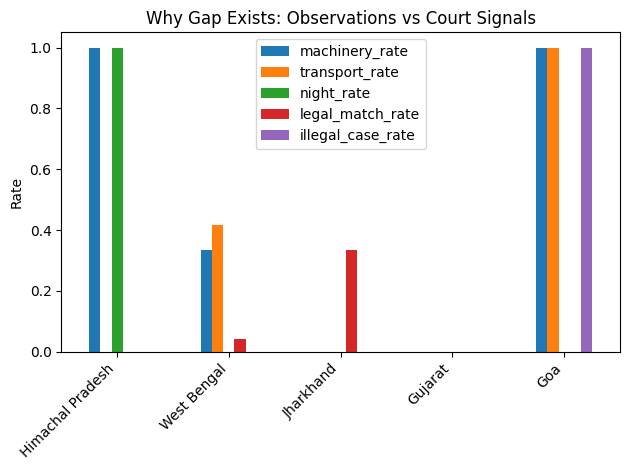

In [66]:
import matplotlib.pyplot as plt

comparison[[
    "machinery_rate", "transport_rate", "night_rate",
    "legal_match_rate", "illegal_case_rate"
]].plot(kind="bar")

plt.title("Why Gap Exists: Observations vs Court Signals")
plt.ylabel("Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

when it's extremely bad it gets reported otherwise it happens on the daily 